Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data ready: (1152, 15) (1152,) 1929-12-01 → 2025-11-01
  draw 1/20 done
  draw 2/20 done
  draw 3/20 done
  draw 4/20 done
  draw 5/20 done
  draw 6/20 done
  draw 7/20 done
  draw 8/20 done
  draw 9/20 done
  draw 10/20 done
  draw 11/20 done
  draw 12/20 done
  draw 13/20 done
  draw 14/20 done
  draw 15/20 done
  draw 16/20 done
  draw 17/20 done
  draw 18/20 done
  draw 19/20 done
  draw 20/20 done
  draw 1/20 done
  draw 2/20 done
  draw 3/20 done
  draw 4/20 done
  draw 5/20 done
  draw 6/20 done
  draw 7/20 done
  draw 8/20 done
  draw 9/20 done
  draw 10/20 done
  draw 11/20 done
  draw 12/20 done
  draw 13/20 done
  draw 14/20 done
  draw 15/20 done
  draw 16/20 done
  draw 17/20 done
  draw 18/20 done
  draw 19/20 done
  draw 20/20 done
  P  complexity  sharpe_KMZ  sharpe_intercept  r2_KMZ  r2_intercept
  2       0.167      -0.025             0.064 

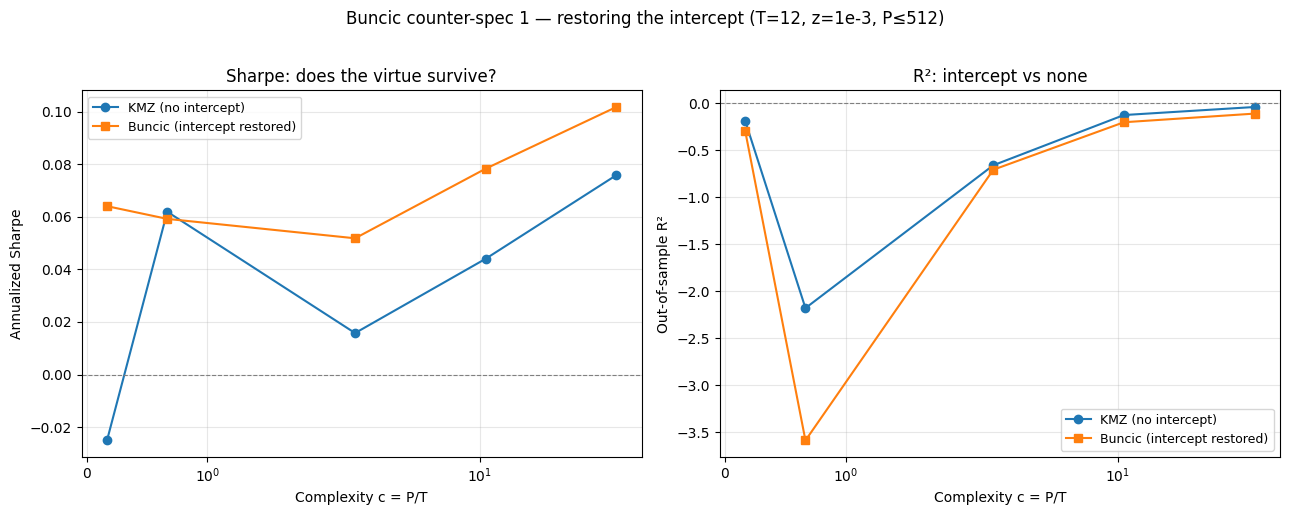

  P  mean   std    p10   p90  complexity
  2 0.064 0.061 -0.010 0.153       0.167
  8 0.059 0.091 -0.048 0.171       0.667
 32 0.052 0.068 -0.034 0.156       2.667
128 0.078 0.071 -0.003 0.170      10.667
512 0.102 0.045  0.063 0.188      42.667


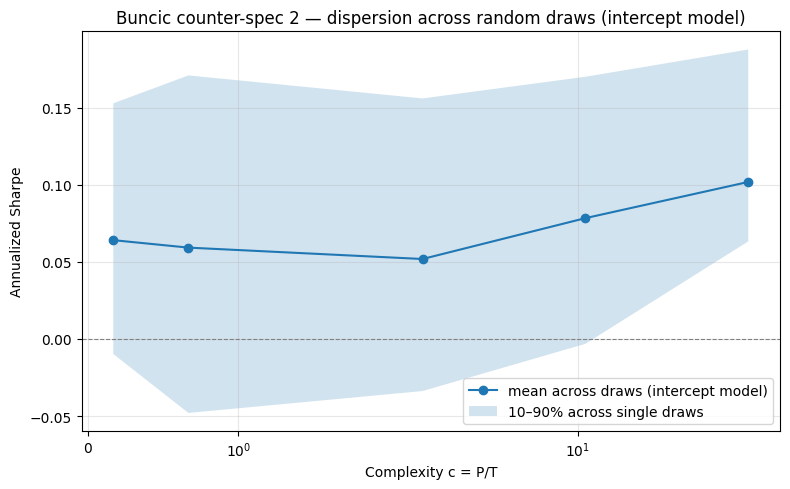

In [3]:
# ==================================================================================
# buncic.ipynb - Phase 3 counter-specifications (Buncic 2025)
# 1. Restore Intercept — KMZ regress with no constant term. Buncic argues this
#    handicaps the simple/low-complexity benchmark (which relies on predicting a
#    baseline mean), inflating the apparent complexity benefit. Counter-spec:
#    add an unpenalized intercept, re-run, measure how much of the result survives.
# 2. Aggregation — KMZ average performance across the 1,000 random draws in a
#    specific way. Buncic argues a more standard aggregation changes the picture.
#    Counter-spec: re-aggregate the stored per-draw results.
# ==================================================================================
from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ = "/content/drive/MyDrive/Summer Research/kmz"
BUNCIC = "/content/drive/MyDrive/Summer Research/debate"

# --- SEED POLICY: draw d uses seed MASTER_SEED*100000 + d (same as kmz_pipeline) ---
MASTER_SEED = 42

# --- engine copied from kmz_pipeline.ipynb — keep in sync ---

def make_rff(G, n_pairs, gamma=2.0, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((n_pairs, G.shape[1])).T   # draw j is the same no matter what n_pairs is
    proj = gamma * (G @ W)
    S = np.empty((G.shape[0], 2 * n_pairs))
    S[:, 0::2] = np.sin(proj)                          # sin/cos interleaved, so the first P columns are P/2 full pairs
    S[:, 1::2] = np.cos(proj)
    return S

# --- sanity check: first P columns must be P/2 sin/cos pairs, independent of n_pairs ---
_G = np.random.default_rng(1).standard_normal((5, 15))
assert np.allclose(make_rff(_G, n_pairs=4, seed=0), make_rff(_G, n_pairs=100, seed=0)[:, :8]), "make_rff is the old version"

def ridge_forecast_dual(S_tr, R_tr, S_t, z):
    """KMZ baseline: dual-form ridge, NO intercept."""
    T = S_tr.shape[0]
    K = (S_tr @ S_tr.T) / T
    a = np.linalg.solve(K + z*np.eye(T), R_tr/T)
    return float(S_t @ (S_tr.T @ a))

def run_oos_nested(S_full, R, P, T, z, forecaster=ridge_forecast_dual):
    """Recursive OOS pass. `forecaster` lets us swap the estimator (baseline vs intercept)."""
    assert P % 2 == 0, "P must be even so no sin/cos pair is split"
    S_all = S_full[:, :P]
    N = len(R)
    fc, sr = [], []
    for t in range(T, N):
        S_tr = S_all[t-T:t]; R_tr = R[t-T:t]
        sd = S_tr.std(axis=0); sd[sd == 0] = 1.0
        S_tr_z = S_tr / sd
        S_t_z  = S_all[t] / sd
        f = forecaster(S_tr_z, R_tr, S_t_z, z)
        fc.append(f); sr.append(f * R[t])
    return np.array(fc), np.array(sr)

def run_sweep(G, R, P_grid, z, T, n_draws=20, master_seed=MASTER_SEED,
              forecaster=ridge_forecast_dual):
    """Complexity sweep; `forecaster` selects the estimator. Returns averaged + per-draw."""
    R_oos = R[T:]; Pmax = max(P_grid); rows = []
    for d in range(n_draws):
        S_full = make_rff(G, n_pairs=Pmax//2, gamma=2.0, seed=master_seed*100000 + d)
        for P in P_grid:
            f, sr = run_oos_nested(S_full, R, P, T, z, forecaster=forecaster)
            r2 = 1 - np.sum((R_oos - f)**2)/np.sum(R_oos**2)
            rows.append(dict(P=P, complexity=P/T, draw=d, z=z, T=T,
                             r2=r2, sharpe=sr.mean()/sr.std()*np.sqrt(12)))
        print(f"  draw {d+1}/{n_draws} done")
    per_draw = pd.DataFrame(rows)
    sweep = (per_draw.groupby("P")
             .agg(complexity=("complexity","first"),
                  r2=("r2","mean"), sharpe=("sharpe","mean")).reset_index())
    return sweep, per_draw


# --- data prep copied from kmz_pipeline.ipynb — keep in sync ---
predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]

panel = pd.read_parquet(f"{KMZ}/predictors.parquet")
panel = panel.sort_values("date").reset_index(drop=True)
panel["target"] = panel["excess_ret"].shift(-1)          # align: predictors_t → return_{t+1}

def expanding_standardize(s, min_periods=36):
    sd = s.expanding(min_periods=min_periods).std().shift(1)
    return s / sd
def vol_standardize_returns(r, window=12):
    rms = np.sqrt((r**2).rolling(window).mean()).shift(1)
    return r / rms

std = panel.copy()
for c in predictors:
    std[c] = expanding_standardize(panel[c])
std["target_std"] = vol_standardize_returns(panel["target"])
std = std.dropna(subset=predictors + ["target_std"]).reset_index(drop=True)

G = std[predictors].to_numpy()
R = std["target"].to_numpy()
print("data ready:", G.shape, R.shape, std["date"].min().date(), "→", std["date"].max().date())

# ============================================================
# Counter-spec 1 — restore the intercept
# ------------------------------------------------------------
# KMZ regress with NO intercept. Buncic argues this handicaps the simple/low-
# complexity benchmark (which relies on predicting a baseline mean), inflating
# the apparent complexity benefit. We restore an UNPENALIZED intercept, same
# seeds, and compare.
#
# Uses the PRIMAL solve (prepend a ones-column, invert the (P+1)x(P+1) system,
# intercept left unpenalized) — correct by construction. Primal is O(P^3), so
# we cap the grid at P=512 (c up to ~43 — deep enough to show whether the curves
# cross). Very-high-complexity intercept behavior (c=500, 1000) is left as a noted
# limitation.
# ============================================================

def ridge_forecast_intercept_primal(S_tr, R_tr, S_t, z):
    """Ridge WITH an unpenalized intercept, primal form (correct by construction).

    Prepend a ones-column so the model can fit a constant baseline (the intercept).
    Leave that intercept UNPENALIZED (pen[0,0]=0) — shrink the slopes but not the
    constant, else we'd partly re-impose the zero-intercept restriction.
    """
    T = S_tr.shape[0]
    S_tr_i = np.concatenate([np.ones((T, 1)), S_tr], axis=1)
    S_t_i  = np.concatenate([[1.0], S_t])
    P = S_tr_i.shape[1]
    A   = (S_tr_i.T @ S_tr_i) / T
    pen = z * np.eye(P); pen[0, 0] = 0.0
    beta = np.linalg.solve(A + pen, (S_tr_i.T @ R_tr) / T)
    return float(S_t_i @ beta)


# --- baseline (no intercept) vs intercept, SAME seeds, matched grid ---
P_grid_int = [2, 8, 32, 128, 512]

sweep_base, sweep_base_raw = run_sweep(
    G, R, P_grid_int, z=1e-3, T=12, n_draws=20,
    forecaster=ridge_forecast_dual)                # KMZ baseline (no intercept)

sweep_int, sweep_int_raw = run_sweep(
    G, R, P_grid_int, z=1e-3, T=12, n_draws=20,
    forecaster=ridge_forecast_intercept_primal)    # Buncic (intercept restored)

# save per-draw results so counter-spec 2 needs no rerun
sweep_base_raw.to_parquet(f"{KMZ}/buncic_base_raw.parquet")
sweep_int_raw.to_parquet(f"{KMZ}/buncic_int_raw.parquet")

# --- comparison table ---
cmp = sweep_base[["P", "complexity", "sharpe"]].rename(columns={"sharpe": "sharpe_KMZ"})
cmp["sharpe_intercept"] = sweep_int["sharpe"].values
cmp["r2_KMZ"]           = sweep_base["r2"].values
cmp["r2_intercept"]     = sweep_int["r2"].values
print(cmp.round(3).to_string(index=False))

# --- comparison plot ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(sweep_base["complexity"], sweep_base["sharpe"], "o-", label="KMZ (no intercept)")
ax[0].plot(sweep_int["complexity"],  sweep_int["sharpe"],  "s-", label="Buncic (intercept restored)")
ax[0].set_ylabel("Annualized Sharpe"); ax[0].set_title("Sharpe: does the virtue survive?")
ax[1].plot(sweep_base["complexity"], sweep_base["r2"], "o-", label="KMZ (no intercept)")
ax[1].plot(sweep_int["complexity"],  sweep_int["r2"],  "s-", label="Buncic (intercept restored)")
ax[1].set_ylabel("Out-of-sample R²"); ax[1].set_title("R²: intercept vs none")
for a in ax:
    a.set_xscale("symlog"); a.axhline(0, color="grey", lw=.8, ls="--")
    a.set_xlabel("Complexity c = P/T"); a.legend(fontsize=9); a.grid(alpha=.3)
plt.suptitle("Buncic counter-spec 1 — restoring the intercept (T=12, z=1e-3, P≤512)", y=1.02)
plt.tight_layout(); plt.show()
fig.savefig(f"{BUNCIC}/buncic_intercept.png", dpi=150, bbox_inches="tight")


# --- Counter-spec 2: aggregation ---
# KMZ-style: mean of per-draw Sharpes
# Buncic-style: the DISTRIBUTION of single-draw Sharpes — how much does one
#   realistic draw vary? A single investor gets one draw, not the average.

raw = sweep_int_raw
agg = (raw.groupby("P")["sharpe"]
          .agg(mean="mean", std="std",
               p10=lambda s: s.quantile(.10),
               p90=lambda s: s.quantile(.90))
          .reset_index())
agg["complexity"] = agg["P"]/12
print(agg.round(3).to_string(index=False))

# plot mean with the 10-90 spread across draws
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(agg["complexity"], agg["mean"], "o-", label="mean across draws (intercept model)")
ax.fill_between(agg["complexity"], agg["p10"], agg["p90"], alpha=.2,
                label="10–90% across single draws")
ax.set_xscale("symlog"); ax.axhline(0, color="grey", lw=.8, ls="--")
ax.set_xlabel("Complexity c = P/T"); ax.set_ylabel("Annualized Sharpe")
ax.set_title("Buncic counter-spec 2 — dispersion across random draws (intercept model)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
fig.savefig(f"{BUNCIC}/buncic_dispersion.png", dpi=150, bbox_inches="tight")